Author: B282025 <br>
MSc Bioinformatics Dissertation <br>
August 2026 <br>
 
## Fibronectin Spatial Transcriptomic Analysis

Description: This notebook contains code to explore CosMx6k spatial transcriptomic data and analyze fibronectin expression.

References: https://scverse-tutorials.readthedocs.io/en/latest/notebooks/anndata_getting_started.html<br>
This code was written using the scverse tutorial linked above and manual scripting, with some code incorporated from Claude Sonnet 5.


In [59]:
# Import packages
import anndata
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib as mpl
import itertools

In [60]:
# ---------------------------------------------------------------------
# Shared plot styling (kept identical across all analysis notebooks)
# ---------------------------------------------------------------------

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
    "savefig.bbox": "tight",
})

### Read in the AnnData Object

The Seurat object was downloaded from the GEO (Accession: GSE282059). An R script (convert_spatial_to_anndata.Rmd) was used to convert the Seurat object to an AnnData object for analysis in Python. This data object contains the RNA transcript count data, the published cell type annotations, and the computed PCA and UMAP components.

In [61]:
# Load in the cell annotation data
adata = anndata.read_h5ad('../CosMx_Data/Published_Data/GSE282059_anndata_object.h5ad')

In [62]:
print(adata)
print(adata.X) # X is the active data matrix which holds the cell annotations

AnnData object with n_obs × n_vars = 523855 × 5749
    obs: 'cell_ID', 'fov', 'Area', 'sample_ID', 'sample_date', 'Condition', 'x_coord', 'y_coord', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'Area.um2', 'complexity', 'n.Transcripts', 'n.Genes', 'nCount_RNA', 'nFeature_RNA', 'Annotation.Lvl1', 'Annotation.Lvl2', 'InjuryState', 'Niche'
    var: 'DisplayName', 'Barcode', 'CodeClass', 'ProbeID', 'FOV_1_1_count', 'FOV_1_2_count', 'FOV_1_3_count', 'FOV_1_4_count', 'FOV_1_5_count', 'FOV_1_6_count', 'FOV_1_7_count', 'FOV_1_8_count', 'FOV_1_9_count', 'FOV_1_10_count', 'FOV_1_11_count', 'FOV_1_12_count', 'FOV_1_13_count', 'FOV_1_14_count', 'FOV_1_15_count', 'FOV_1_16_count', 'FOV_1_17_count', 'FOV_1_18_count', 'FOV_1_19_count', 'FOV_1_20_count', 'FOV_1_21_count', 'FOV_1_22_count', 'FOV_1_23_count', 'FOV_1_24_count', 'FOV_1_25_count

In [63]:
adata.layers

Layers with keys: counts, data

In [64]:
type(adata.X)

NoneType

In [65]:
# List of cell annotations available
adata.obs.keys()

Index(['cell_ID', 'fov', 'Area', 'sample_ID', 'sample_date', 'Condition',
       'x_coord', 'y_coord', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68',
       'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45',
       'Mean.DAPI', 'Max.DAPI', 'NucAspectRatio', 'Circularity',
       'Eccentricity', 'Perimeter', 'Solidity', 'Area.um2', 'complexity',
       'n.Transcripts', 'n.Genes', 'nCount_RNA', 'nFeature_RNA',
       'Annotation.Lvl1', 'Annotation.Lvl2', 'InjuryState', 'Niche'],
      dtype='object')

In [66]:
"cell_ID" in adata.obs.keys()

True

In [67]:
adata.obs['sample_ID'].value_counts()

sample_ID
UUO2        119004
UUO1        112523
UUO3         81593
UUO4         75042
UUO5         69190
Control6     38276
Control5     28227
Name: count, dtype: int64

In [68]:
adata.obs['sample_date'].value_counts()

sample_date
28/03/22    119004
09.02/22    112523
10/11/22     81593
22/12/22     75042
16/01/23     69190
16/03/22     38276
14/03/22     28227
Name: count, dtype: int64

In [69]:
adata.obs['Annotation.Lvl1'].value_counts()

Annotation.Lvl1
PT                       129452
Fibroblast                74792
Myeloid Cell              44212
Endothelia                40389
SMC/Pericyte              39506
T Cell                    38676
LOH                       33610
B Cell                    30621
Border Region             20786
PC                        19736
DCT/CNT                   15336
IC                        14197
Capsule                    7075
Endothelia Glomerular      6046
PEC                        5078
Podocyte                   4343
Name: count, dtype: int64

In [70]:
adata.obs['Annotation.Lvl2'].value_counts()

Annotation.Lvl2
PT Injured                57670
Myofibroblast             41264
PT                        40876
Endothelia                40389
Fibroblast                33528
PT Inflammatory           30906
B Cell                    26814
T Cell                    24229
SMC/Pericyte              22872
Border Region             20786
Mesangial Cell            15891
cDC                       15034
LOH                       12918
PC Injured                12144
LOH Injured               11608
NK Cell                   10637
Macrophage                10339
LOH Inflammatory           9084
DCT/CNT Injured            8751
IC Injured                 8158
PC                         7592
Capsule                    7075
DCT/CNT                    6585
Endothelia Glomerular      6046
IC                         6039
CD14 Monocyte              5176
PEC                        5078
Podocyte                   4343
Mast Cell                  3856
Treg                       3810
Plasma Cell             

In [71]:
adata.obs['InjuryState'].value_counts()

InjuryState
Other               198187
Non-PT Epithelia     82879
PT Injured           57670
Myeloid Cell         44212
Myofibroblast        41264
PT                   40876
PT Inflammatory      30906
Border Region        20786
Capsule               7075
Name: count, dtype: int64

In [72]:
adata.obs['Niche'].value_counts()

Niche
Fibrotic Niche       176659
Injured Epithelia    157333
Normal Epithelia      86404
Glomeruli             36760
Border Region         20786
TLS                   19732
Blood Vessels         19106
Capsule                7075
Name: count, dtype: int64

In [73]:
adata.obs.shape

(523855, 33)

In [74]:
# Cell information
# Each row is a cell
adata.obs.head()

,cell_ID,fov,Area,sample_ID,sample_date,Condition,x_coord,y_coord,Mean.PanCK,Max.PanCK,...,Area.um2,complexity,n.Transcripts,n.Genes,nCount_RNA,nFeature_RNA,Annotation.Lvl1,Annotation.Lvl2,InjuryState,Niche
c_2_100_10,c_2_100_10,100,5585,UUO5,16/01/23,UUO,10.781644,17.528931,1268,6436,...,80.801020,1.532773,912.0,595.0,891.0,576,Border Region,Border Region,Border Region,Border Region
c_2_100_1000,c_2_100_1000,100,5347,UUO5,16/01/23,UUO,10.764684,17.182522,889,1932,...,77.357753,1.524064,285.0,187.0,280.0,182,B Cell,B Cell,Other,Fibrotic Niche
c_2_100_1001,c_2_100_1001,100,3617,UUO5,16/01/23,UUO,10.795235,17.182281,1350,4036,...,52.328968,1.277778,138.0,108.0,135.0,105,T Cell,NK Cell,Other,Fibrotic Niche
c_2_100_1002,c_2_100_1002,100,3517,UUO5,16/01/23,UUO,10.604470,17.183484,572,1400,...,50.882218,1.415385,276.0,195.0,271.0,190,Border Region,Border Region,Border Region,Border Region
c_2_100_1003,c_2_100_1003,100,4985,UUO5,16/01/23,UUO,10.401315,17.182883,946,1808,...,72.120516,1.227545,205.0,167.0,202.0,164,Border Region,Border Region,Border Region,Border Region


In [75]:
adata.obs['Condition'].value_counts()

Condition
UUO        457352
Control     66503
Name: count, dtype: int64

'Condition' contains the UUO (Obstructed) vs control (Non-Obstructed) tissue section information.

In [76]:
print(adata.obs_names[:5])

Index(['c_2_100_10', 'c_2_100_1000', 'c_2_100_1001', 'c_2_100_1002',
       'c_2_100_1003'],
      dtype='object')


In [77]:
# Gene annotation information
# var contains gene annotation information
adata.var.head()

,DisplayName,Barcode,CodeClass,ProbeID,FOV_1_1_count,FOV_1_2_count,FOV_1_3_count,FOV_1_4_count,FOV_1_5_count,FOV_1_6_count,...,FOV_2_319_count,FOV_2_320_count,FOV_2_321_count,FOV_2_322_count,RawTargetMean,RawTargetSDS,backgroundTestpVals,qcFlagsBackground,qcFlagsQuantileSummary,qcProbesFlagged
A1BG,A1BG,......YY..........................GG.............,Endogenous,<NA>,1021.0,864.0,1144.0,1239.0,961.0,1450.0,...,6714.0,5100.0,6136.0,6244.0,3.669793,5.124383,0.0,Pass,Pass,False
A2M,A2M,........GG......YY................GG......BB.....,Endogenous,<NA>,50.0,61.0,96.0,127.0,105.0,86.0,...,42.0,51.0,34.0,43.0,0.189388,0.669243,0.0,Pass,Pass,False
AAAS,AAAS,........BB........RR....GGYY.....................,Endogenous,<NA>,21.0,27.0,44.0,55.0,51.0,28.0,...,32.0,25.0,30.0,46.0,0.034619,0.196582,0.0,Pass,Pass,False
AAK1,AAK1,YY..........YY......YY............BB.............,Endogenous,<NA>,65.0,53.0,105.0,91.0,99.0,67.0,...,37.0,36.0,60.0,56.0,0.070352,0.295911,0.0,Pass,Pass,False
AAMP,AAMP,..........BB..........YY......YY..BB.............,Endogenous,<NA>,49.0,48.0,40.0,66.0,50.0,59.0,...,71.0,73.0,79.0,87.0,0.071063,0.300350,0.0,Pass,Pass,False


In [78]:
adata.var_names[:20]

Index(['A1BG', 'A2M', 'AAAS', 'AAK1', 'AAMP', 'AARS1', 'AASS', 'ABAT', 'ABCA1',
       'ABCA5', 'ABCB1', 'ABCB10', 'ABCB7', 'ABCB8', 'ABCB9', 'ABCC1', 'ABCC3',
       'ABCC4', 'ABCC8', 'ABCC9'],
      dtype='object')

In [79]:
'FN1' in adata.var_names

True

Fibronectin is in the gene list.

In [80]:
# Access the layers
# Layers are different versions of the data, e.g. log transformed or raw counts
#print(adata.layers)
print(adata.layers["counts"])
#print(adata.layers["counts"].data)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 142734050 stored elements and shape (523855, 5749)>
  Coords	Values
  (0, 0)	4.0
  (0, 17)	1.0
  (0, 62)	1.0
  (0, 63)	1.0
  (0, 71)	1.0
  (0, 73)	1.0
  (0, 74)	1.0
  (0, 77)	1.0
  (0, 87)	1.0
  (0, 89)	1.0
  (0, 94)	1.0
  (0, 106)	2.0
  (0, 113)	1.0
  (0, 116)	1.0
  (0, 137)	1.0
  (0, 158)	1.0
  (0, 163)	1.0
  (0, 181)	1.0
  (0, 187)	1.0
  (0, 220)	1.0
  (0, 221)	1.0
  (0, 227)	1.0
  (0, 240)	2.0
  (0, 250)	1.0
  (0, 257)	1.0
  :	:
  (523854, 5214)	2.0
  (523854, 5221)	1.0
  (523854, 5222)	2.0
  (523854, 5231)	1.0
  (523854, 5250)	2.0
  (523854, 5251)	2.0
  (523854, 5253)	1.0
  (523854, 5256)	1.0
  (523854, 5298)	1.0
  (523854, 5299)	1.0
  (523854, 5302)	1.0
  (523854, 5321)	1.0
  (523854, 5347)	2.0
  (523854, 5408)	1.0
  (523854, 5409)	1.0
  (523854, 5434)	2.0
  (523854, 5443)	2.0
  (523854, 5457)	1.0
  (523854, 5475)	2.0
  (523854, 5512)	1.0
  (523854, 5539)	1.0
  (523854, 5561)	1.0
  (523854, 5570)	2.0
  (523854, 5599)	1

The data only has a single additional layer, the raw counts, which are accessible via the layer key 'counts'.

### Interacting with Annotations

Cell annotation information lives in adata.obs

In [81]:
adata.obs["Annotation.Lvl2"]

c_2_100_10      Border Region
c_2_100_1000           B Cell
c_2_100_1001          NK Cell
c_2_100_1002    Border Region
c_2_100_1003    Border Region
                    ...      
c_2_96_733      Myofibroblast
c_2_97_785         Fibroblast
c_2_9_1022         Endothelia
c_2_9_1601      Myofibroblast
c_2_9_255              T Cell
Name: Annotation.Lvl2, Length: 523855, dtype: object

In [82]:
print(sum(adata.obs["Annotation.Lvl2"] == "PT Injured"))

57670


In [83]:
adata.obsm

AxisArrays with keys: pca, umap

In [84]:
for key in adata.obsm:
    print(key, adata.obsm[key].shape, sep="\t")

pca	(523855, 20)
umap	(523855, 2)


In [85]:
adata.obsm.keys()

KeysView(AxisArrays with keys: pca, umap)

### UMAP Plots

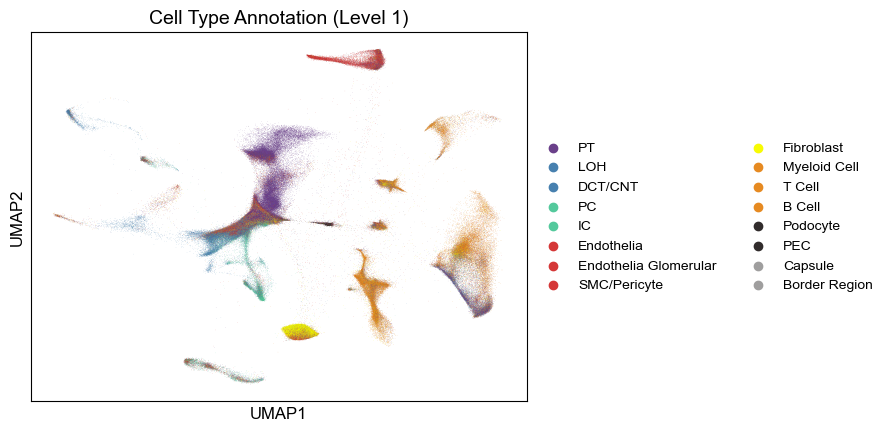

In [86]:
sc.pl.umap(
    adata,
    color="Annotation.Lvl1",
    palette={
        "PT": "#6A408A",
        "LOH": "#4780AF",
        "DCT/CNT": "#4780AF",
        "PC": "#54C99C",
        "IC": "#54C99C",
        "Endothelia": "#D53737",
        "Endothelia Glomerular": "#D53737",
        "SMC/Pericyte": "#D53737",
        "Fibroblast": "#F7FB03",
        "Myeloid Cell": "#E68A21",
        "T Cell": "#E68A21",
        "B Cell": "#E68A21",
        "Podocyte": "#312C2C",
        "PEC": "#312C2C",
        "Capsule": "#9F9E9E",
        "Border Region": "#9F9E9E",
    },
    title="Cell Type Annotation (Level 1)",
)

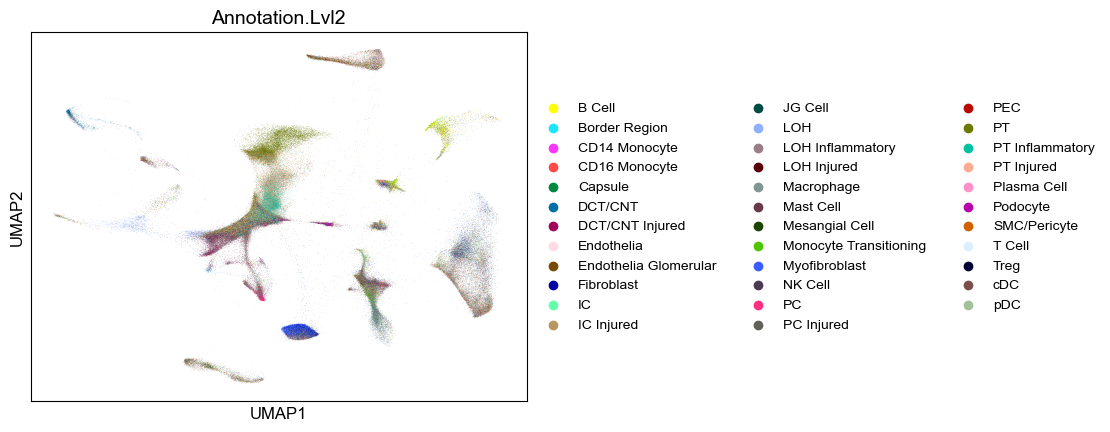

In [87]:
sc.pl.umap(adata, color="Annotation.Lvl2")

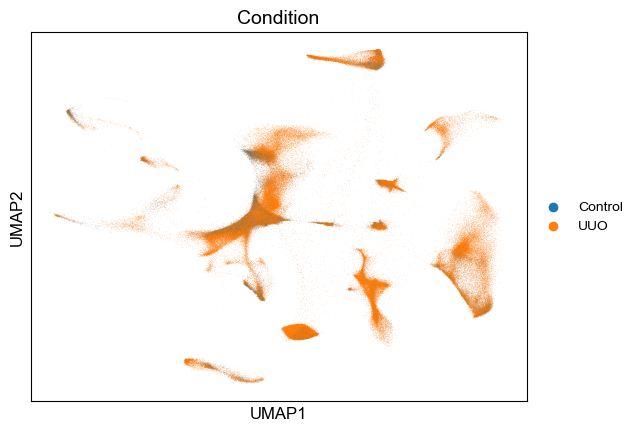

In [88]:
sc.pl.umap(adata, color="Condition")

In [89]:
adata.obs["cell_ID"].is_unique

True

### Plot cell type abundance

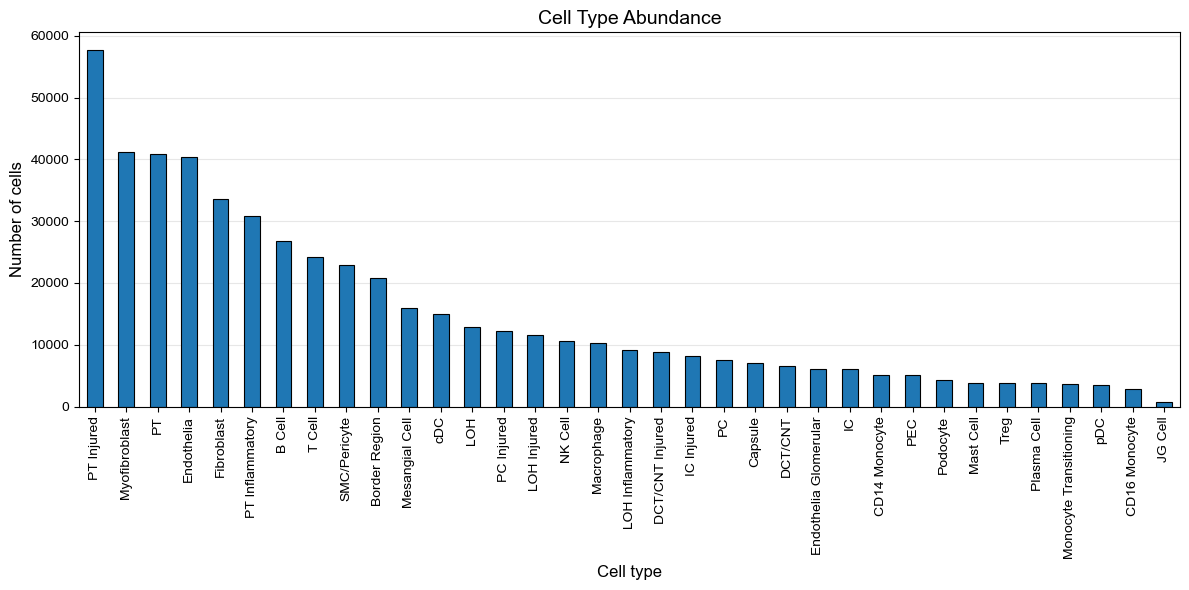

In [90]:
# Plot cell type abundance

# Count cells per cell type
celltype_counts = (adata.obs["Annotation.Lvl2"].value_counts().sort_values(ascending=False))

# Plot
plt.figure(figsize=(12, 6))

ax = celltype_counts.plot(kind="bar", edgecolor="black", linewidth=0.8)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", alpha=0.3)

plt.ylabel("Number of cells")
plt.xlabel("Cell type")
plt.title("Cell Type Abundance")

plt.tight_layout()
plt.show()

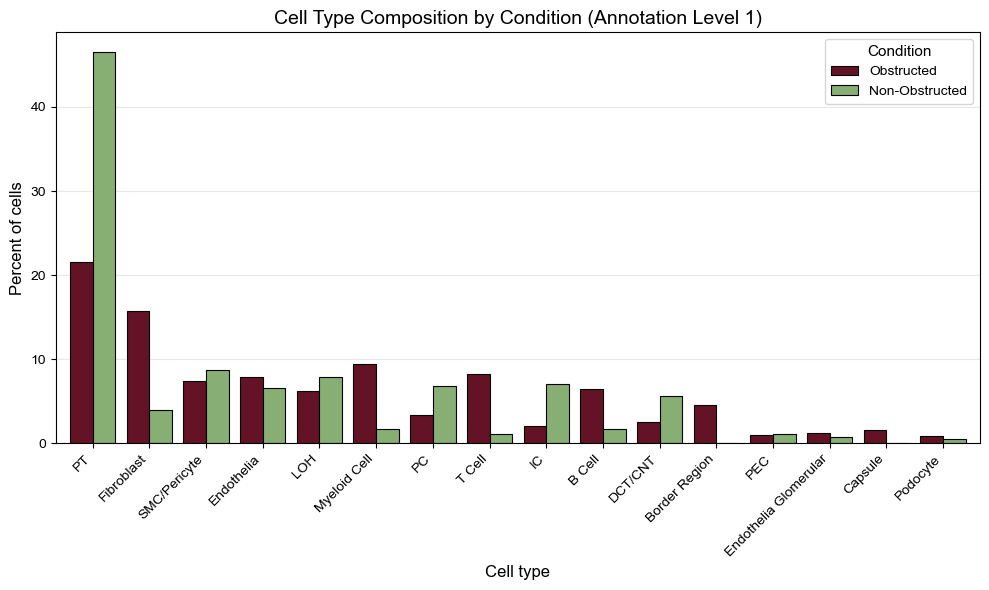

In [91]:
# Calculate percentages for each condition
rename_map = {"UUO": "Obstructed", "Control": "Non-Obstructed"}

percent_dict = {}

for cond in adata.obs["Condition"].unique():

    sub = adata[adata.obs["Condition"] == cond]

    percent_dict[rename_map.get(cond, cond)] = (
        sub.obs["Annotation.Lvl1"]
        .value_counts(normalize=True)
        * 100
    )

# Combine into one DataFrame
celltype_percent = pd.DataFrame(percent_dict).fillna(0)

# Optional: order cell types by average abundance
celltype_percent = celltype_percent.loc[
    celltype_percent.mean(axis=1).sort_values(ascending=False).index
]

# Plot grouped bar chart
ax = celltype_percent.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.8,
    color=["#641226", "#87AE73"],   # Obstructed, Non-Obstructed
    edgecolor="black", linewidth=0.8,
)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", alpha=0.3)

ax.set_ylabel("Percent of cells")
ax.set_xlabel("Cell type")
ax.set_title("Cell Type Composition by Condition (Annotation Level 1)")
ax.legend(title="Condition")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [92]:
celltype_percent

,Obstructed,Non-Obstructed
Annotation.Lvl1,,
PT,21.535710,46.551283
Fibroblast,15.783685,3.917117
SMC/Pericyte,7.372877,8.700359
Endothelia,7.868775,6.617747
LOH,6.211408,7.822204
Myeloid Cell,9.414849,1.733756
PC,3.328071,6.789167
T Cell,8.292300,1.129272
IC,2.073020,7.091409


In [93]:
Obstructed_tubules = 21.535710 + 6.211408 + 3.328071 + 2.073020 + 2.542462
Obstructed_tubules


35.690671

In [94]:
NonObK_tubules = 46.551283 + 7.822204 + 6.789167 + 7.091409 + 5.575688
NonObK_tubules

73.829751

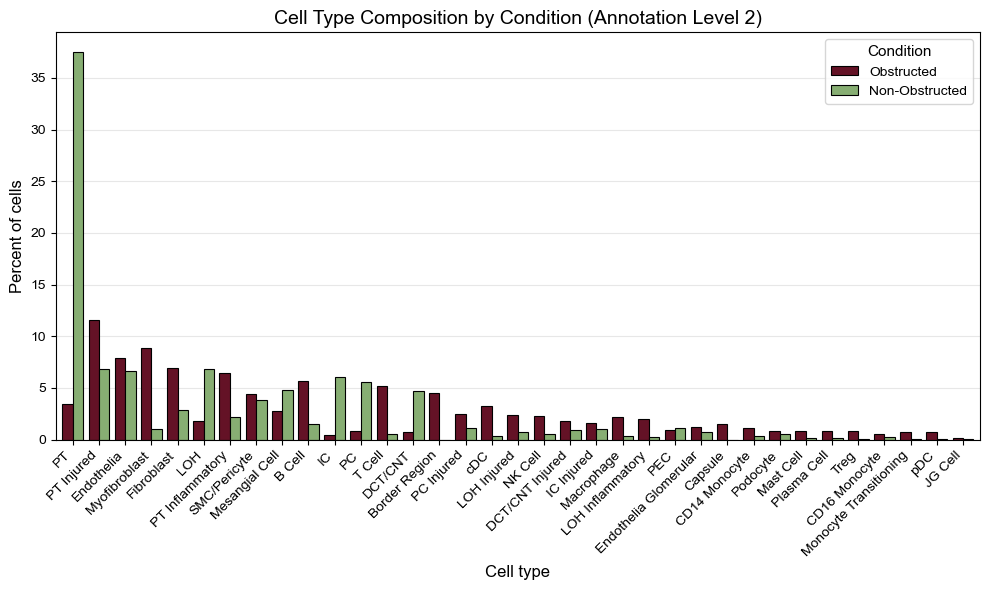

In [95]:
# Calculate percentages for each condition
rename_map = {"UUO": "Obstructed", "Control": "Non-Obstructed"}

percent_dict = {}

for cond in adata.obs["Condition"].unique():

    sub = adata[adata.obs["Condition"] == cond]

    percent_dict[rename_map.get(cond, cond)] = (
        sub.obs["Annotation.Lvl2"]
        .value_counts(normalize=True)
        * 100
    )

# Combine into one DataFrame
celltype_percent = pd.DataFrame(percent_dict).fillna(0)

# Optional: order cell types by average abundance
celltype_percent = celltype_percent.loc[
    celltype_percent.mean(axis=1).sort_values(ascending=False).index
]

# Plot grouped bar chart
ax = celltype_percent.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.8,
    color=["#641226", "#87AE73"],   # Obstructed, Non-Obstructed
    edgecolor="black", linewidth=0.8,
)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", alpha=0.3)

ax.set_ylabel("Percent of cells")
ax.set_xlabel("Cell type")
ax.set_title("Cell Type Composition by Condition (Annotation Level 2)")
ax.legend(title="Condition")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [96]:
celltype_percent

,Obstructed,Non-Obstructed
Annotation.Lvl2,,
PT,3.478940,37.539660
PT Injured,11.620808,6.799693
Endothelia,7.868775,6.617747
Myofibroblast,8.872816,1.028525
Fibroblast,6.910870,2.888591
LOH,1.827695,6.855330
PT Inflammatory,6.435962,2.211930
SMC/Pericyte,4.437938,3.872006
Mesangial Cell,2.779916,4.777228


### Cell type composition by condition (stacked bar)

Alternative view of the two grouped bar charts above: one bar per Condition,
with segments stacked and colored by cell type (instead of one bar per cell
type, grouped by Condition). Each bar sums to 100%, so this emphasizes the
overall composition shift between Obstructed and Non-Obstructed tissue,
rather than per-cell-type side-by-side comparison.

In [97]:
def _qualitative_colors(n):
    """Return n visually distinct colors by chaining several tab20-family
    colormaps together (60 colors total before repeating). Annotation.Lvl2
    has more categories than any single qualitative colormap provides."""
    base = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
    return list(itertools.islice(itertools.cycle(base), n))


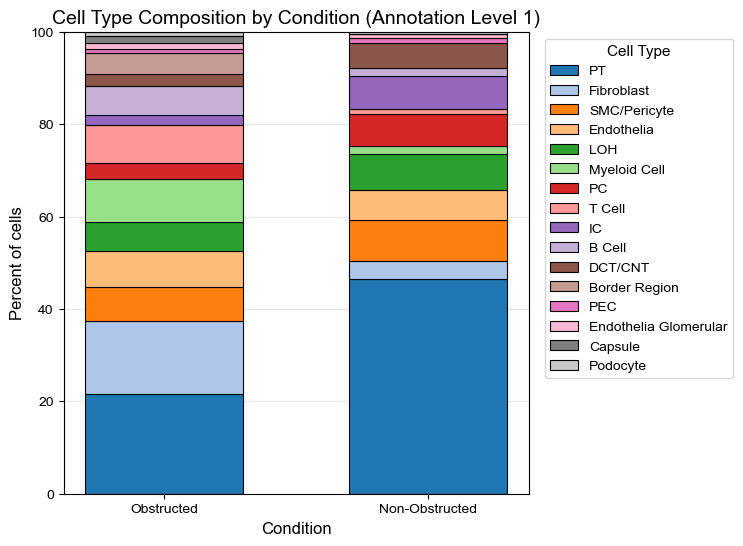

In [98]:
# Stacked bar chart: cell type composition by condition (Annotation Level 1)
rename_map = {"UUO": "Obstructed", "Control": "Non-Obstructed"}

percent_dict = {}
for cond in adata.obs["Condition"].unique():
    sub = adata[adata.obs["Condition"] == cond]
    percent_dict[rename_map.get(cond, cond)] = (
        sub.obs["Annotation.Lvl1"].value_counts(normalize=True) * 100
    )

celltype_percent_lvl1 = pd.DataFrame(percent_dict).fillna(0)

# --- Customize stacking order and colors here ---
# Set a list of cell type names (bottom-to-top of the stack, matching legend
# order) to control the order. Leave as None to order by average abundance
# (descending), which is the previous default behavior.
CELL_TYPE_ORDER_LVL1 = None


CELL_TYPE_COLORS_LVL1 = {}

if CELL_TYPE_ORDER_LVL1 is not None:
    cell_types_lvl1 = [ct for ct in CELL_TYPE_ORDER_LVL1 if ct in celltype_percent_lvl1.index]
    cell_types_lvl1 += [ct for ct in celltype_percent_lvl1.index if ct not in cell_types_lvl1]
else:
    cell_types_lvl1 = list(
        celltype_percent_lvl1.mean(axis=1).sort_values(ascending=False).index
    )
celltype_percent_lvl1 = celltype_percent_lvl1.loc[cell_types_lvl1]

conditions_lvl1 = list(celltype_percent_lvl1.columns)
_default_colors_lvl1 = _qualitative_colors(len(cell_types_lvl1))
colors_lvl1 = [
    CELL_TYPE_COLORS_LVL1.get(ct, _default_colors_lvl1[i])
    for i, ct in enumerate(cell_types_lvl1)
]

fig, ax = plt.subplots(figsize=(6, 6))
x = np.arange(len(conditions_lvl1))
bottoms = np.zeros(len(conditions_lvl1))

for ct, color in zip(cell_types_lvl1, colors_lvl1):
    values = celltype_percent_lvl1.loc[ct, conditions_lvl1].to_numpy()
    ax.bar(x, values, bottom=bottoms, width=0.6, label=ct, color=color,
           edgecolor="black", linewidth=0.8)
    bottoms += values

ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(conditions_lvl1)
ax.set_ylim(0, 100)
ax.set_ylabel("Percent of cells")
ax.set_xlabel("Condition")
ax.set_title("Cell Type Composition by Condition (Annotation Level 1)")
ax.legend(title="Cell Type", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.savefig("celltype_composition_stacked_lvl1.png", dpi=300, bbox_inches="tight")
plt.show()


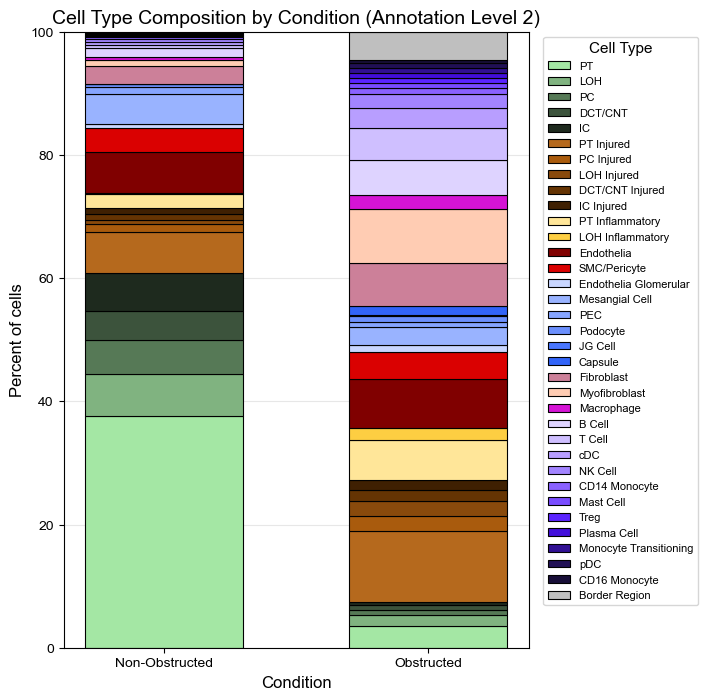

In [99]:
# Stacked bar chart: cell type composition by condition (Annotation Level 2)
rename_map = {"UUO": "Obstructed", "Control": "Non-Obstructed"}

percent_dict = {}
for cond in adata.obs["Condition"].unique():
    sub = adata[adata.obs["Condition"] == cond]
    percent_dict[rename_map.get(cond, cond)] = (
        sub.obs["Annotation.Lvl2"].value_counts(normalize=True) * 100
    )

celltype_percent_lvl2 = pd.DataFrame(percent_dict).fillna(0)

# --- Customize stacking order and colors here ---
# Set a list of cell type names (bottom-to-top of the stack, matching legend
# order) to control the order. Leave as None to order by average abundance
# (descending), which is the previous default behavior.
# NOTE: this same list is passed to the custom dot plot below (via
# CELL_TYPE_ORDER_LVL2), so setting it here keeps both plots in sync.
CELL_TYPE_ORDER_LVL2 = [
    # Healthy Tubule
    "PT",
    "LOH",
    "PC",
    "DCT/CNT",
    "IC",
    # Injured Tubule
    "PT Injured",
    "PC Injured",
    "LOH Injured",
    "DCT/CNT Injured",
    "IC Injured",
    # Inflamed Tubule
    "PT Inflammatory",
    "LOH Inflammatory",
    # Vascular cells
    "Endothelia",
    "SMC/Pericyte",
    # Glomeruli cells
    "Endothelia Glomerular",
    "Mesangial Cell",
    "PEC",
    "Podocyte",
    "JG Cell",
    "Capsule",
    # Fibroblasts
    "Fibroblast",
    # Myofibroblasts
    "Myofibroblast",
    # Macrophages
    "Macrophage",
    # Non-macrophage immune cells
    "B Cell",
    "T Cell",
    "cDC",
    "NK Cell",
    "CD14 Monocyte",
    "Mast Cell",
    "Treg",
    "Plasma Cell",
    "Monocyte Transitioning",
    "pDC",
    "CD16 Monocyte",
    # Other
    "Border Region"
]


CELL_TYPE_COLORS_LVL2 = {
    # Healthy Tubule
    "PT": "#a4e7a4",
    "LOH": "#80b380",
    "PC": "#567956",
    "DCT/CNT": "#3c533c",
    "IC": "#1e2a1e",
    # Injured Tubule
    "PT Injured": "#b5691d",
    "PC Injured": "#a95b0d",
    "LOH Injured": "#894a0c",
    "DCT/CNT Injured": "#653403",
    "IC Injured": "#3f2002",
    # Inflamed Tubule
    "PT Inflammatory": "#ffe699",
    "LOH Inflammatory": "#fdce42",
    # Vascular cells
    "Endothelia": "#800000",
    "SMC/Pericyte": "#DA0101",
    # Glomeruli cells
    "Endothelia Glomerular": "#c9d6ff",
    "Mesangial Cell": "#99b3ff",
    "PEC": "#86a5ff",
    "Podocyte": "#6b8ffc",
    "JG Cell": "#4a77fe",
    "Capsule": "#3264f8",
    # Fibroblasts
    "Fibroblast": "#cc8099",
    # Myofibroblasts
    "Myofibroblast": "#ffccb3",
    # Macrophages
    "Macrophage": "#d514d5",
    # Non-macrophage immune cells
    "B Cell": "#ded3ff",
    "T Cell": "#CFBFFF",
    "cDC": "#b89eff",
    "NK Cell": "#a284ff",
    "CD14 Monocyte": "#8A62FF",
    "Mast Cell": "#794CFF",
    "Treg": "#5B24FF",
    "Plasma Cell": "#420fdb",
    "Monocyte Transitioning": "#311093",
    "pDC": "#211055",
    "CD16 Monocyte": "#180e38",
    # Other
    "Border Region": "#bfbfbf"
}


if CELL_TYPE_ORDER_LVL2 is not None:
    cell_types_lvl2 = [ct for ct in CELL_TYPE_ORDER_LVL2 if ct in celltype_percent_lvl2.index]
    cell_types_lvl2 += [ct for ct in celltype_percent_lvl2.index if ct not in cell_types_lvl2]
else:
    cell_types_lvl2 = list(
        celltype_percent_lvl2.mean(axis=1).sort_values(ascending=False).index
    )
celltype_percent_lvl2 = celltype_percent_lvl2.loc[cell_types_lvl2]

conditions_lvl2 = ["Non-Obstructed", "Obstructed"]
_default_colors_lvl2 = _qualitative_colors(len(cell_types_lvl2))
colors_lvl2 = [
    CELL_TYPE_COLORS_LVL2.get(ct, _default_colors_lvl2[i])
    for i, ct in enumerate(cell_types_lvl2)
]

fig, ax = plt.subplots(figsize=(6, 8))
x = np.arange(len(conditions_lvl2))
bottoms = np.zeros(len(conditions_lvl2))

for ct, color in zip(cell_types_lvl2, colors_lvl2):
    values = celltype_percent_lvl2.loc[ct, conditions_lvl2].to_numpy()
    ax.bar(x, values, bottom=bottoms, width=0.6, label=ct, color=color,
           edgecolor="black", linewidth=0.8)
    bottoms += values

ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(conditions_lvl2)
ax.set_ylim(0, 100)
ax.set_ylabel("Percent of cells")
ax.set_xlabel("Condition")
ax.set_title("Cell Type Composition by Condition (Annotation Level 2)")
ax.legend(title="Cell Type", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1, fontsize=8)

fig.savefig("celltype_composition_stacked_lvl2.png", dpi=300, bbox_inches="tight")
plt.show()


## FN1 Analysis

In [100]:
# Extract FN1 from the raw counts layer
fn1_idx = adata.var_names.get_loc("FN1") # gets the location of the FN1 data
fn1_counts = adata.layers["counts"][:, fn1_idx] # extract the column
type(fn1_counts)

scipy.sparse._csr.csr_matrix

In [101]:
# Convert from a sparse matrix to an array
fn1_counts = fn1_counts.toarray().flatten()

In [102]:
# Add the FN1 counts as a column to the working X array
adata.obs["FN1_counts"] = fn1_counts

In [103]:
# Check the distribution of the FN1 counts in the AnnData object
adata.obs["FN1_counts"].describe()

count    523855.000000
mean          0.032629
std           0.237253
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          22.000000
Name: FN1_counts, dtype: float64

In [104]:
adata.obs["FN1_counts"].value_counts()

FN1_counts
0.0     509746
1.0      12175
2.0       1491
3.0        247
4.0         86
5.0         37
6.0         27
7.0         15
9.0          6
10.0         4
12.0         4
13.0         3
8.0          3
21.0         2
14.0         2
15.0         2
16.0         1
20.0         1
19.0         1
22.0         1
17.0         1
Name: count, dtype: int64

In [105]:
# Define FN1+ cells as having 2 or more FN1 transcripts
adata.obs["FN1_positive"] = (adata.obs["FN1_counts"] >= 2) 

This creates a list of booleans. 
David confirmed the two transcript threshold.

In [106]:
adata.obs["FN1_positive"].value_counts()

FN1_positive
False    521921
True       1934
Name: count, dtype: int64

In [107]:
prevalence = ((adata.obs[adata.obs["FN1_positive"]==True].shape[0])/(adata.obs["FN1_positive"].shape[0]))*100
print(prevalence)

0.36918612974964443


0.369% of cells express two or more fibronectin transcripts

In [108]:
# Check the cell types
adata.obs["Annotation.Lvl2"].value_counts()

Annotation.Lvl2
PT Injured                57670
Myofibroblast             41264
PT                        40876
Endothelia                40389
Fibroblast                33528
PT Inflammatory           30906
B Cell                    26814
T Cell                    24229
SMC/Pericyte              22872
Border Region             20786
Mesangial Cell            15891
cDC                       15034
LOH                       12918
PC Injured                12144
LOH Injured               11608
NK Cell                   10637
Macrophage                10339
LOH Inflammatory           9084
DCT/CNT Injured            8751
IC Injured                 8158
PC                         7592
Capsule                    7075
DCT/CNT                    6585
Endothelia Glomerular      6046
IC                         6039
CD14 Monocyte              5176
PEC                        5078
Podocyte                   4343
Mast Cell                  3856
Treg                       3810
Plasma Cell             

In [109]:
# Create a cell type summary table
celltype_summary = (
    adata.obs
    .groupby("Annotation.Lvl2")
    .agg(
        n_cells=("FN1_counts", "size"), # counts how many cells belong to each cell type
        n_positive=("FN1_positive", "sum"), # number of FN1 positive cells -- doesn't account for the level of expression
        percent_positive=("FN1_positive", "mean"), # positive cells/total cells for each type
        mean_FN1=("FN1_counts", "mean"), # number of FN1 transcripts/total number of cells -- tells you which cell types produce the most fibronectin
        median_FN1=("FN1_counts", "median") # median will be zero for many cell types
    )
)

celltype_summary["percent_positive"] *= 100 # convert to a percent out of 100

celltype_summary.sort_values(
    "percent_positive",
    ascending=False
)

/var/folders/99/xct0l8b508x0rlqmy0gj6mc80000gn/T/ipykernel_3002/1300853574.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Annotation.Lvl2")


,n_cells,n_positive,percent_positive,mean_FN1,median_FN1
Annotation.Lvl2,,,,,
Myofibroblast,41264,699,1.693971,0.111598,0.0
JG Cell,743,9,1.211306,0.052490,0.0
Endothelia,40389,298,0.737825,0.052192,0.0
SMC/Pericyte,22872,134,0.585869,0.041579,0.0
Border Region,20786,102,0.490715,0.045415,0.0
Monocyte Transitioning,3566,15,0.420639,0.029725,0.0
IC Injured,8158,29,0.355479,0.030522,0.0
DCT/CNT,6585,23,0.349279,0.025513,0.0
PC Injured,12144,40,0.329381,0.032773,0.0


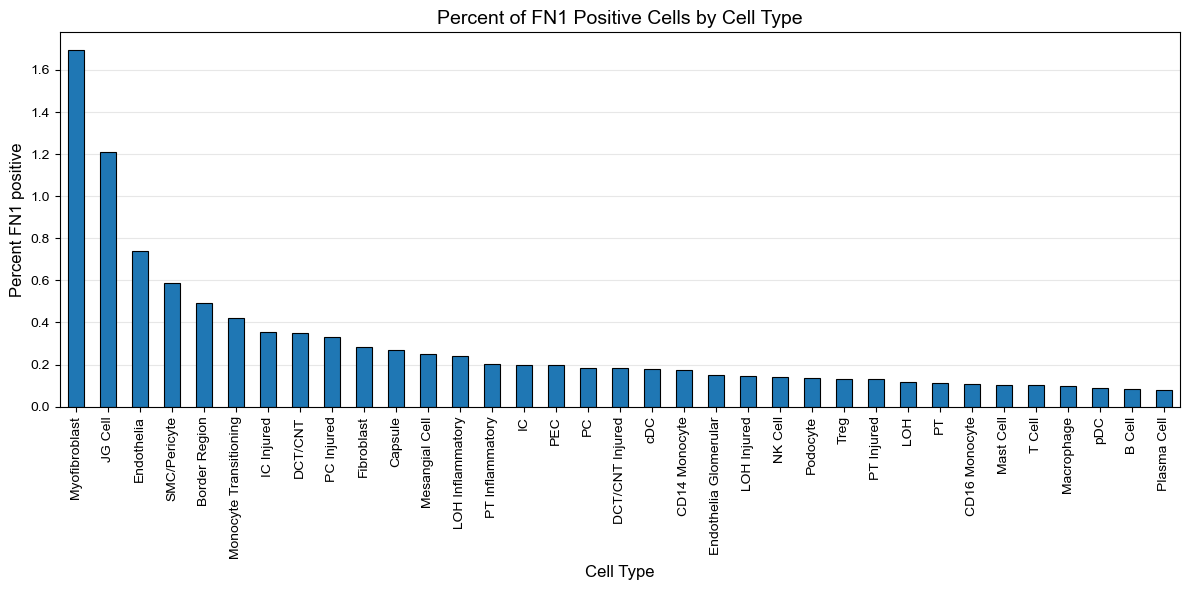

In [110]:
# Visualize
plt.figure(figsize=(12,6))

# Sort the dataframe
plot_df = celltype_summary.sort_values(
    "percent_positive",
    ascending=False
)

ax = plot_df["percent_positive"].plot(kind="bar", edgecolor="black", linewidth=0.8)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", alpha=0.3)

plt.title("Percent of FN1 Positive Cells by Cell Type")
plt.ylabel("Percent FN1 positive")
plt.xlabel("Cell Type")
plt.tight_layout()
plt.show()

/var/folders/99/xct0l8b508x0rlqmy0gj6mc80000gn/T/ipykernel_3002/3941571142.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Annotation.Lvl2", "Condition"])


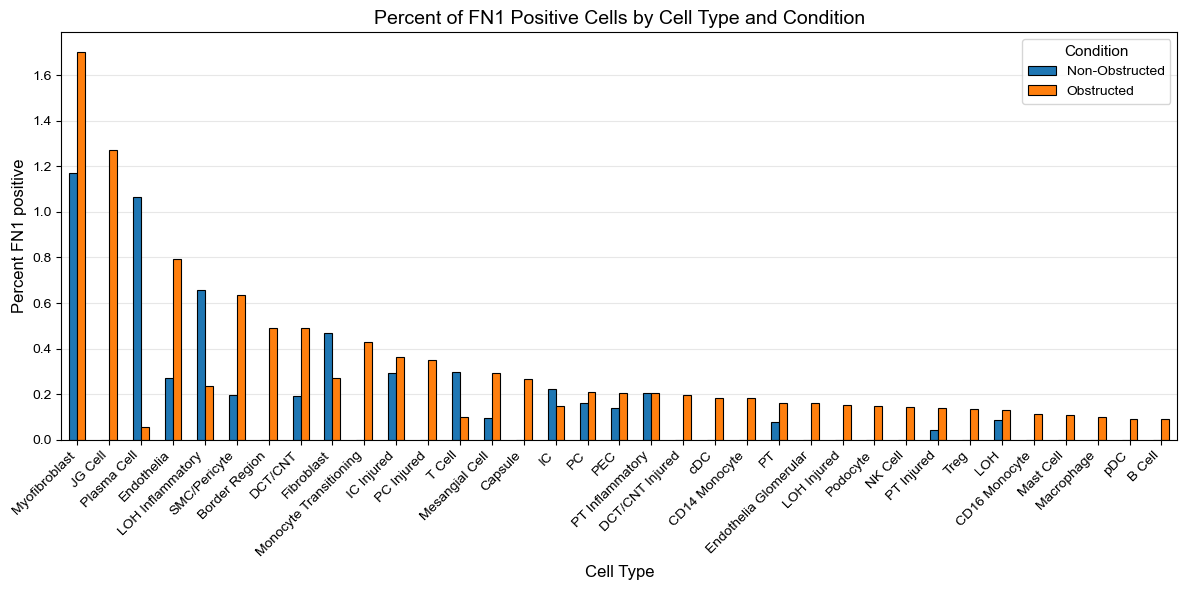

In [111]:
celltype_cond_summary = (
    adata.obs
    .groupby(["Annotation.Lvl2", "Condition"])
    .agg(percent_positive=("FN1_positive", "mean"))
    .reset_index()
)
celltype_cond_summary["percent_positive"] *= 100

# Rename conditions for display (matches the rename used in the other plots).
rename_map = {"UUO": "Obstructed", "Control": "Non-Obstructed"}
celltype_cond_summary["Condition"] = celltype_cond_summary["Condition"].map(
    lambda c: rename_map.get(c, c)
)

# pivot so Condition becomes side-by-side bars
plot_df = celltype_cond_summary.pivot(
    index="Annotation.Lvl2", columns="Condition", values="percent_positive"
)
plot_df = plot_df.loc[plot_df.max(axis=1).sort_values(ascending=False).index]  # sort by highest condition

ax = plot_df.plot(kind="bar", figsize=(12,6), edgecolor="black", linewidth=0.8)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", alpha=0.3)

plt.title("Percent of FN1 Positive Cells by Cell Type and Condition")
plt.ylabel("Percent FN1 positive")
plt.xlabel("Cell Type")
plt.legend(title="Condition")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Remember FN1 positive means 2 or more FN1 transcripts.

/var/folders/99/xct0l8b508x0rlqmy0gj6mc80000gn/T/ipykernel_3002/22001314.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df.groupby(["celltype", "condition"])["expr"].mean()


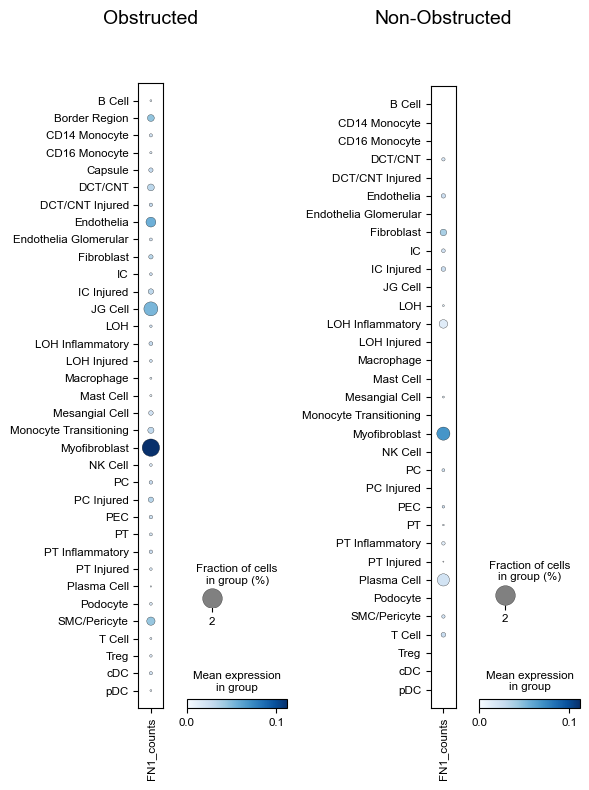

In [112]:
# Dot plot for cell types
# Source: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pl.dotplot.html

# The scale bars are calculated so they are comparable accross categories.

rename_map = {"UUO": "Obstructed", "Control": "Non-Obstructed"}

expr = adata.obs["FN1_counts"]
expr = np.asarray(expr.todense()).flatten() if hasattr(expr, "todense") else np.asarray(expr).flatten()

df = pd.DataFrame({
    "expr": expr,
    "celltype": adata.obs["Annotation.Lvl2"].values,
    "condition": adata.obs["Condition"].values,
})
group_means = df.groupby(["celltype", "condition"])["expr"].mean()
vmax = group_means.max()

conditions = adata.obs["Condition"].unique()
fig, axes = plt.subplots(1, len(conditions), figsize=(6, 8), sharey=True)

for ax, cond in zip(axes, conditions):
    sub = adata[adata.obs["Condition"] == cond]
    sc.pl.dotplot(
        sub,
        var_names=["FN1_counts"],
        groupby="Annotation.Lvl2",
        expression_cutoff=1,
        dot_max=0.02, 
        cmap="Blues",
        vmin=0,
        vmax=vmax,
        ax=ax,
        show=False,
        swap_axes=False,
        title=rename_map.get(cond, str(cond)),
    )

plt.tight_layout()
plt.show()

### Cell type composition and Fibronectin positivity (dot plot)

Alternative to the scanpy dot plot above, this code makes a custom dotplot matching 
the custom dot plot used in the cell-typing (Akoya) notebook: one dot per Annotation.Lvl2 
cell type per Condition, where dot **size** encodes the proportion of that cell type
within the condition (i.e. what fraction of all cells in Obstructed /
Non-Obstructed tissue are this cell type), and dot **shade** encodes the
percent of that cell type's cells that are Fibronectin positive (FN1_counts
greater than or equal to 2, the same threshold used throughout this notebook). 
Both the size scale and the color scale are shared across the two panels so dots 
are directly comparable between conditions.

In [113]:
# ---------------------------------------------------------------------
# Customize the dot plot below.
# ---------------------------------------------------------------------
FIBRONECTIN_CMAP = "Blues"  # colormap for the Fibronectin+ shade
DOT_MAX_SIZE = 400          # largest dot area (points^2)


In [114]:
def plot_celltype_fibronectin_dotplot(adata, annotation_col="Annotation.Lvl2", cell_type_order=None):
    rename_map = {"UUO": "Obstructed", "Control": "Non-Obstructed"}

    # Proportion of cells within each condition that are each cell type.
    percent_dict = {}
    for cond in adata.obs["Condition"].unique():
        sub_cond = adata[adata.obs["Condition"] == cond]
        percent_dict[rename_map.get(cond, cond)] = (
            sub_cond.obs[annotation_col].value_counts(normalize=True) * 100
        )
    proportion_df = pd.DataFrame(percent_dict).fillna(0)

    # Percent Fibronectin positive per cell type per condition.
    fibro_df = (
        adata.obs.groupby([annotation_col, "Condition"])["FN1_positive"]
        .mean()
        .mul(100)
        .rename("percent_positive")
        .reset_index()
    )
    fibro_df["Condition"] = fibro_df["Condition"].map(lambda c: rename_map.get(c, c))
    fibro_pivot = fibro_df.pivot(index=annotation_col, columns="Condition", values="percent_positive")

    # Order cell types by overall abundance (shared across both panels), or
    # use a custom order if one is provided (e.g. to match the stacked bar
    # chart's CELL_TYPE_ORDER_LVL2).
    if cell_type_order is not None:
        cell_types = [ct for ct in cell_type_order if ct in proportion_df.index]
        cell_types += [ct for ct in proportion_df.index if ct not in cell_types]
    else:
        cell_types = proportion_df.mean(axis=1).sort_values(ascending=False).index.tolist()

    # Non-Obstructed panel first, then Obstructed
    conditions = [c for c in ["Non-Obstructed", "Obstructed"] if c in proportion_df.columns]
    conditions += [c for c in proportion_df.columns if c not in conditions]

    proportion_df = proportion_df.reindex(index=cell_types, columns=conditions, fill_value=0)
    fibro_pivot = fibro_pivot.reindex(index=cell_types, columns=conditions)

    # Shared scales so dot size and shade are directly comparable between panels.
    size_max = proportion_df.to_numpy().max()
    color_min = np.nanmin(fibro_pivot.to_numpy())
    color_max = np.nanmax(fibro_pivot.to_numpy())

    def proportion_to_size(p):
        # Dot area (points^2) scales linearly with the proportion value.
        if pd.isna(p) or not size_max:
            return 0
        return (p / size_max) * DOT_MAX_SIZE

    fig_height = max(6, len(cell_types) * 0.3)
    fig, axes = plt.subplots(
        1, len(conditions),
        figsize=(1 * len(conditions) + 2, fig_height),
        sharey=True,
    )
    if len(conditions) == 1:
        axes = [axes]

    y = np.arange(len(cell_types))[::-1]  # top-to-bottom order

    scatter_ref = None
    for ax, cond in zip(axes, conditions):
        proportions = proportion_df[cond].to_numpy()
        pct_fibro = fibro_pivot[cond].to_numpy()
        sizes = [proportion_to_size(p) for p in proportions]

        scatter_ref = ax.scatter(
            np.zeros(len(cell_types)), y,
            s=sizes, c=pct_fibro, cmap=FIBRONECTIN_CMAP,
            vmin=color_min, vmax=color_max,
            edgecolor="black", linewidth=0.8, zorder=3,
        )

        ax.set_axisbelow(True)
        ax.grid(axis="y", linestyle="-", alpha=0.2)
        ax.set_xticks([0])
        ax.set_xticklabels([cond])
        ax.set_xlim(-1, 1)
        ax.tick_params(axis="x", length=0)

    axes[0].set_yticks(y)
    axes[0].set_yticklabels(cell_types, fontsize=8)
    axes[0].set_ylabel(annotation_col)

    # Title placement scales with figure height (rather than a fixed fraction)
    # so it stays close to the axes regardless of how many cell types there are.
    fig.suptitle(
        "Cell Type Composition and FN1 Positivity by Condition",
        y=1 - 0.3 / fig_height,
    )
    fig.subplots_adjust(top=1 - 0.5 / fig_height)

    cbar = fig.colorbar(scatter_ref, ax=axes, orientation="vertical", fraction=0.05, pad=0.08)
    cbar.set_label("FN1 Positive (%)")

    # Size legend: reference dots for a few proportion values, capped at the
    # largest proportion actually present in the data.
    size_legend_values = [v for v in [1, 5, 20] if v <= size_max] or [round(size_max, 1)]
    size_handles = [
        plt.Line2D([0], [0], marker="o", linestyle="none", color="white",
                   markeredgecolor="black", markeredgewidth=0.8,
                   markersize=np.sqrt(proportion_to_size(v)), label=f"{v:.0f}%")
        for v in size_legend_values
    ]
    fig.legend(handles=size_handles, title="Proportion of\nCells in Tissue",
               bbox_to_anchor=(1.05, 0.5), loc="center left", labelspacing=1.8, borderpad=1.4)

    # bbox_inches="tight" expands the saved image to include the colorbar and
    # size legend (both drawn outside the axes), so nothing gets cropped.
    fig.savefig("celltype_fibronectin_dotplot_lvl2.png", dpi=300, bbox_inches="tight")
    plt.show()


/var/folders/99/xct0l8b508x0rlqmy0gj6mc80000gn/T/ipykernel_3002/111073425.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby([annotation_col, "Condition"])["FN1_positive"]


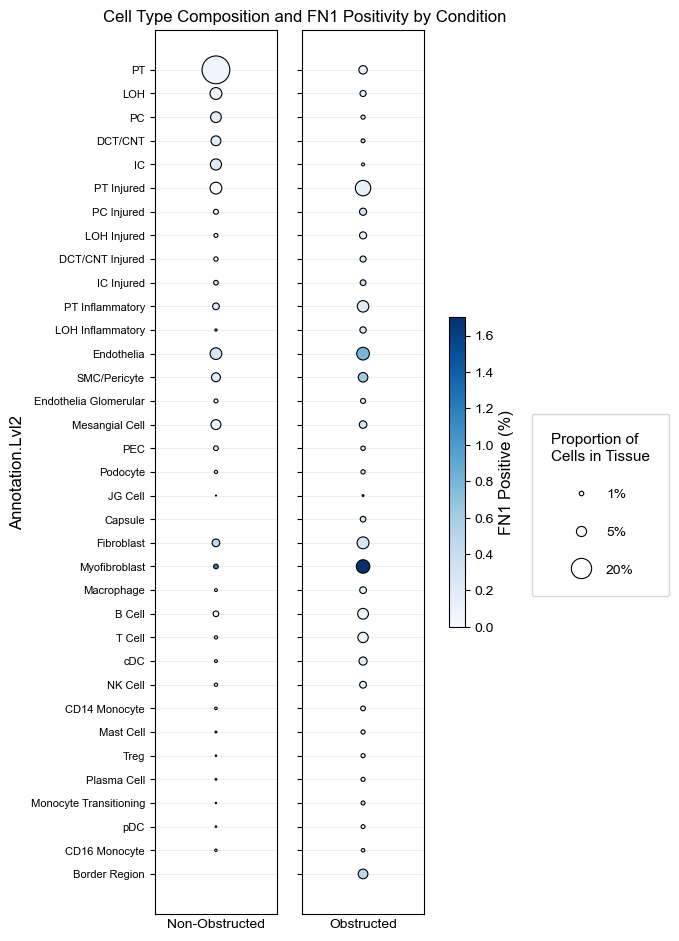

In [115]:
plot_celltype_fibronectin_dotplot(
    adata, annotation_col="Annotation.Lvl2", cell_type_order=CELL_TYPE_ORDER_LVL2
)


UMAP showing fibronectin positivity

/opt/anaconda3/envs/kidney-st/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


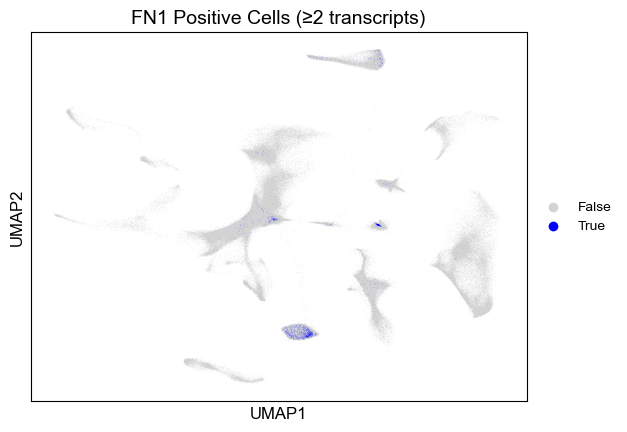

In [116]:
adata.obs["FN1_positive"] = adata.obs["FN1_positive"].astype("category")
adata_sorted = adata[adata.obs["FN1_positive"].sort_values().index]
sc.pl.umap(adata_sorted, 
           color="FN1_positive", 
           palette={True: "blue", False: "lightgrey"},
           title="FN1 Positive Cells (≥2 transcripts)"
           )
